[2026-07-11 01:21:23] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59


             date instrument    factor
0      2024-01-02  000006.SZ -0.000821
1      2024-01-02  000012.SZ -0.000041
2      2024-01-02  000016.SZ  0.000248
3      2024-01-02  000019.SZ  0.000252
4      2024-01-02  000025.SZ -0.000368
...           ...        ...       ...
241765 2024-12-31  688766.SH -0.000695
241766 2024-12-31  688776.SH -0.000440
241767 2024-12-31  688779.SH -0.000325
241768 2024-12-31  688789.SH -0.000985
241769 2024-12-31  688798.SH -0.000505

[241770 rows x 3 columns]
[2026-07-11 01:21:38] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-11 01:21:39] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-11 01:21:42] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-11 01:21:44] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-11 01:21:44] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-11 01:21:44] [info     ] ========== 数据检查 ==========
[2026-07-11 01:21:44] [

时段,IC
2024-01-15~2024-02-08,0.0018
2024-09-24~2024-10-08,-0.0002

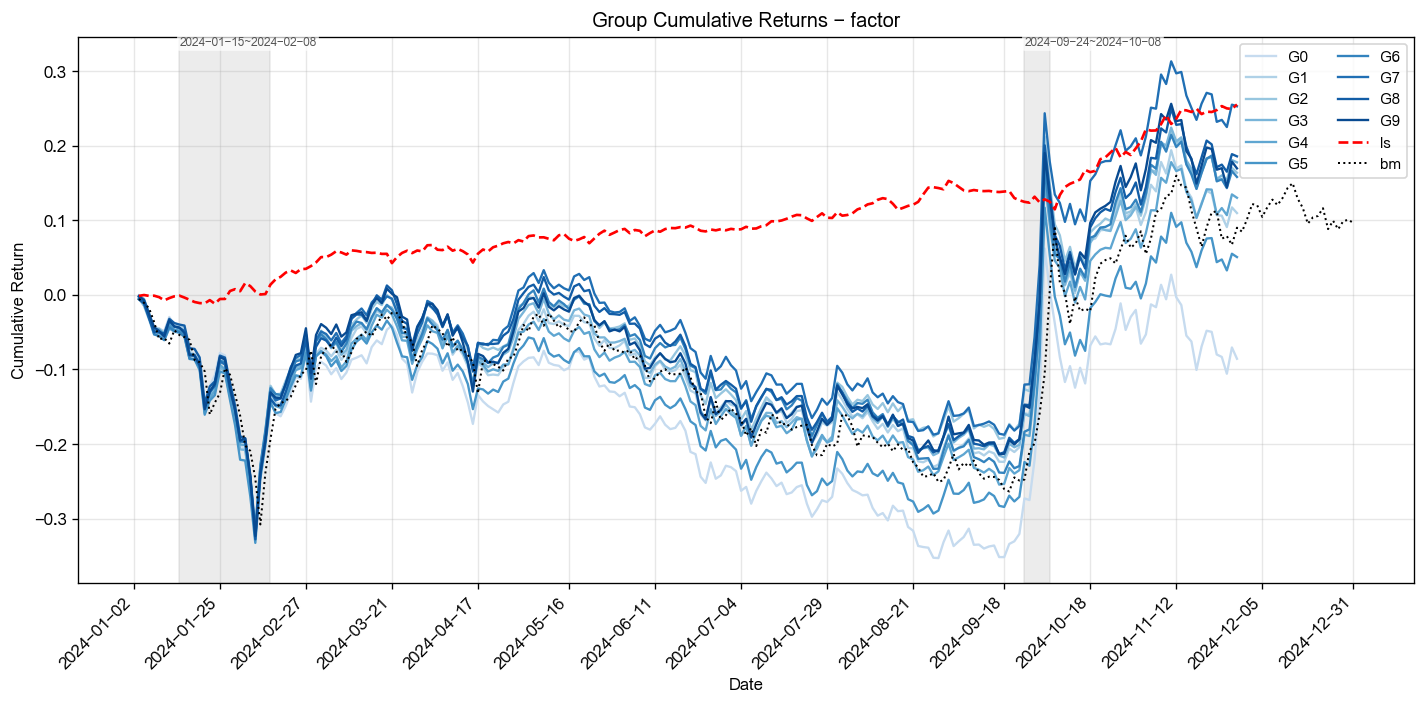
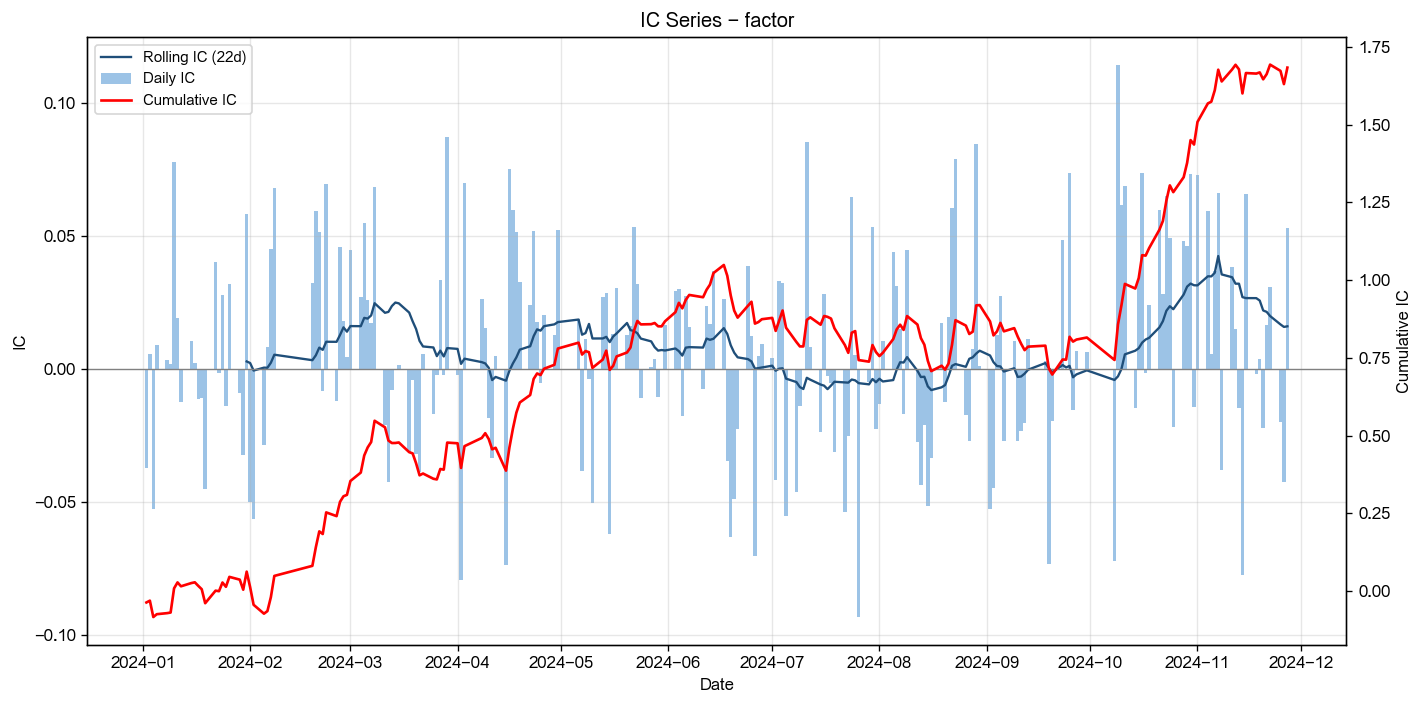
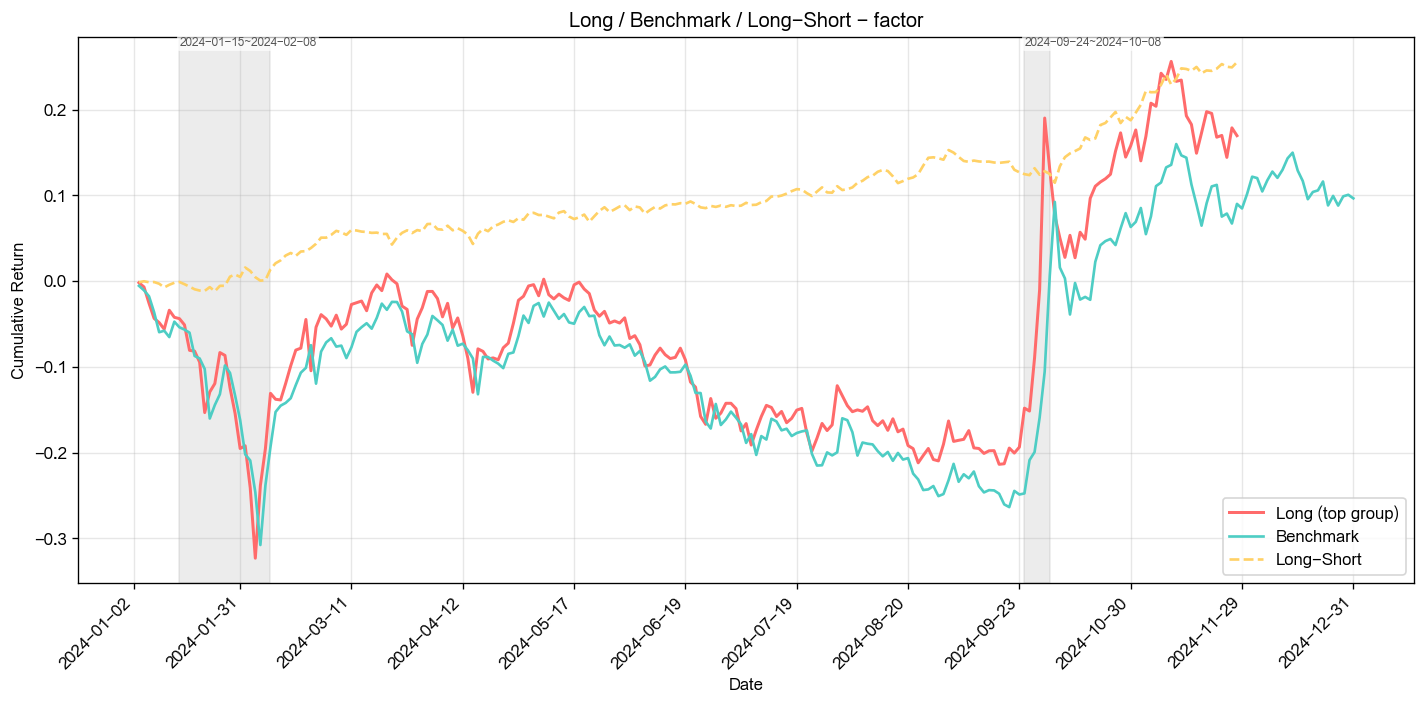
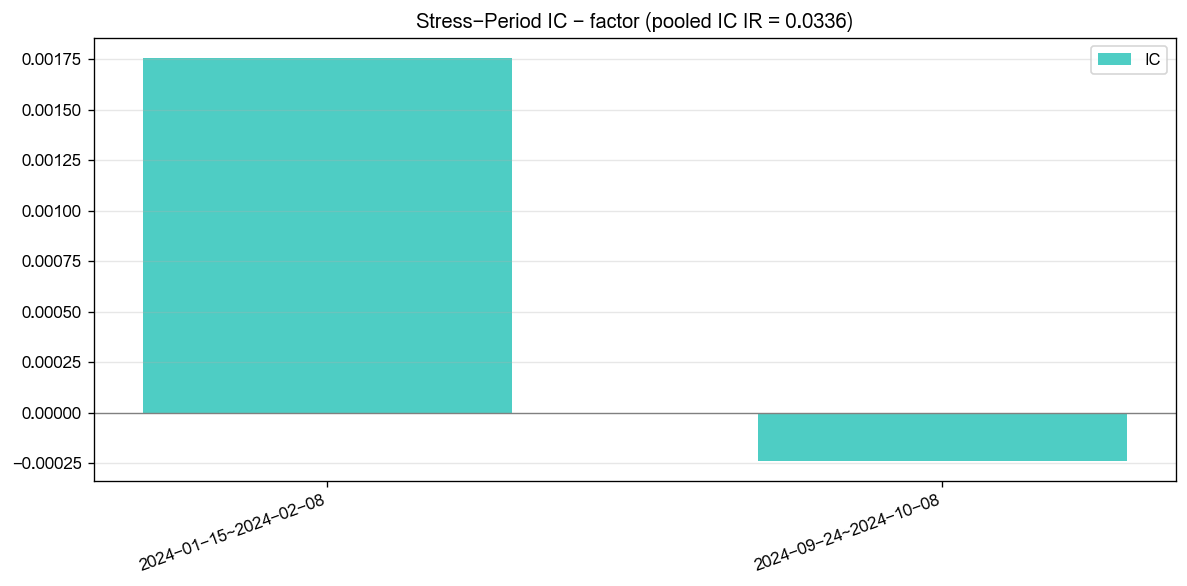
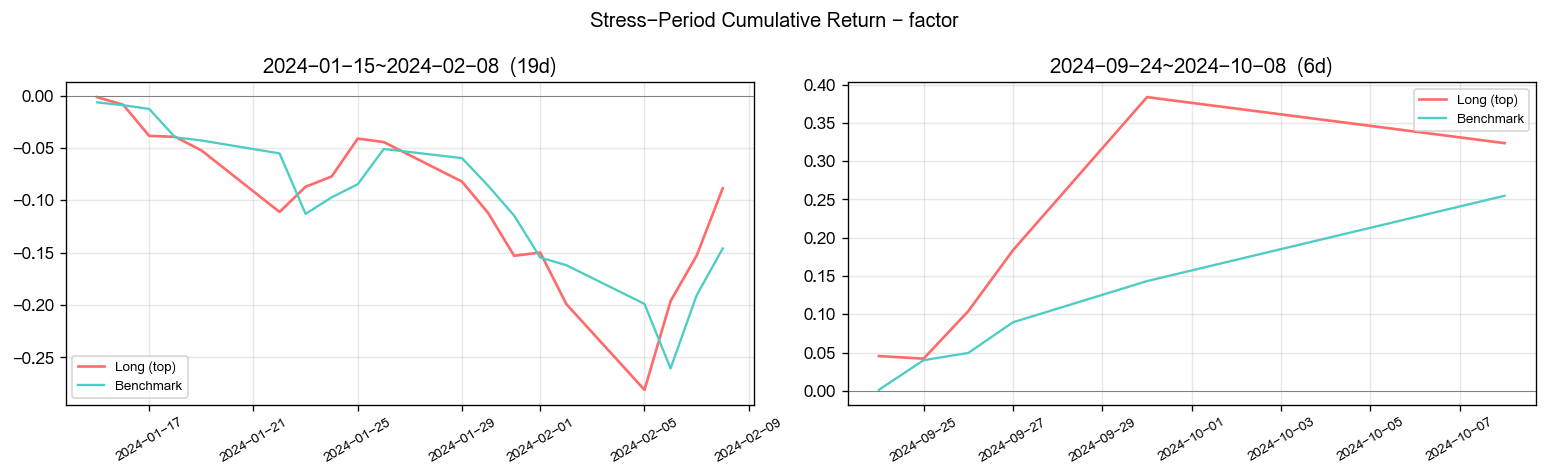

[2026-07-11 01:21:57] [info     ] ========== 因子池回归 ==========
[2026-07-11 01:21:57] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-11 01:21:58] [info     ] 获取收益率数据, 耗时: 0.7374 秒
[2026-07-11 01:21:58] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.4627 秒
[2026-07-11 01:21:58] [info     ] 统计 回归结果, 耗时: 0.0145 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.2461,0.0051,0.0023,1.0000
2,rsi_12,1.9420,0.0444,0.0229,1.0000
3,amount,1.6787,0.0183,0.0109,0.9000
4,netflow_amount_rate_main,1.5324,0.0100,0.0065,1.0000
5,netflow_amount_main,1.5170,0.0252,0.0166,1.0000
6,gross_profit_rate_ttm,1.5060,0.0069,0.0046,1.0000
7,net_profit_rate_ttm,1.4429,0.0040,0.0028,0.8000
8,pb,1.4194,0.0097,0.0068,1.0000
9,bias_20,1.4177,0.0292,0.0206,0.9000
10,cci_14,1.3928,0.0338,0.0243,1.0000

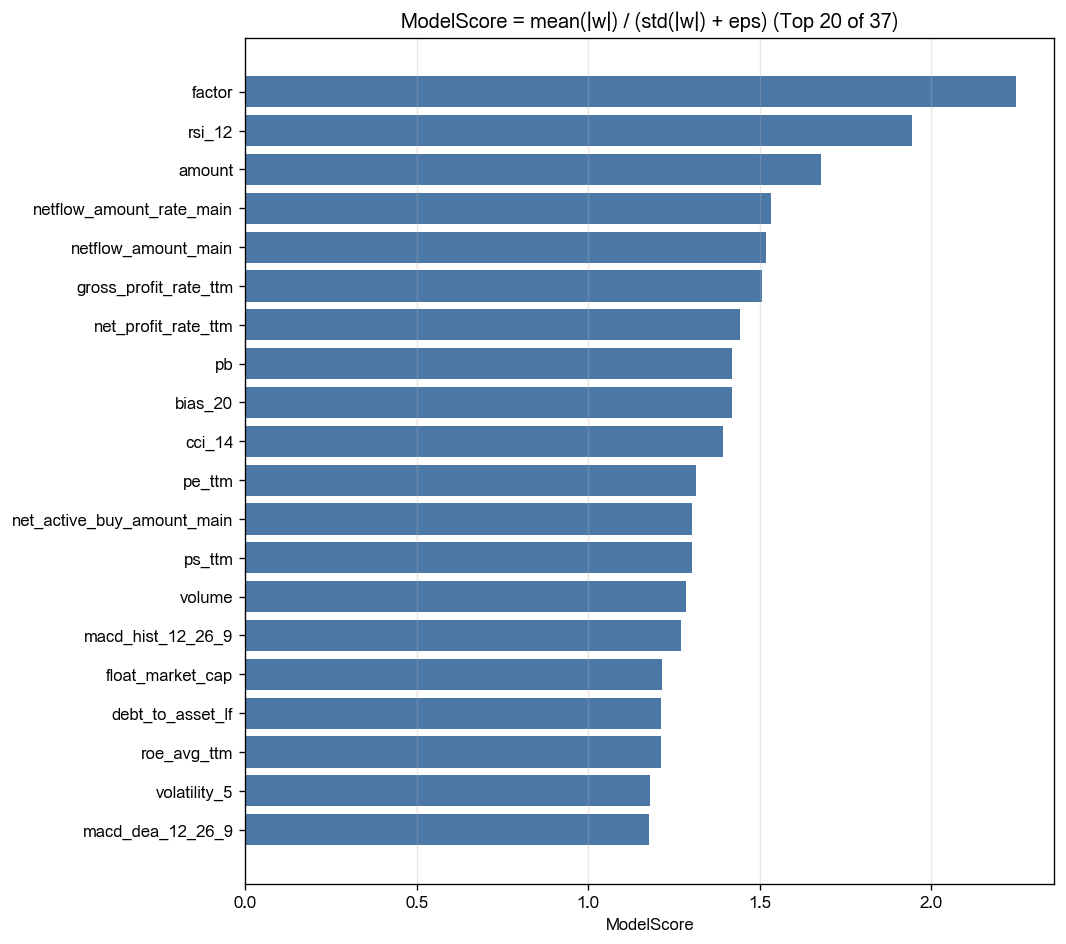
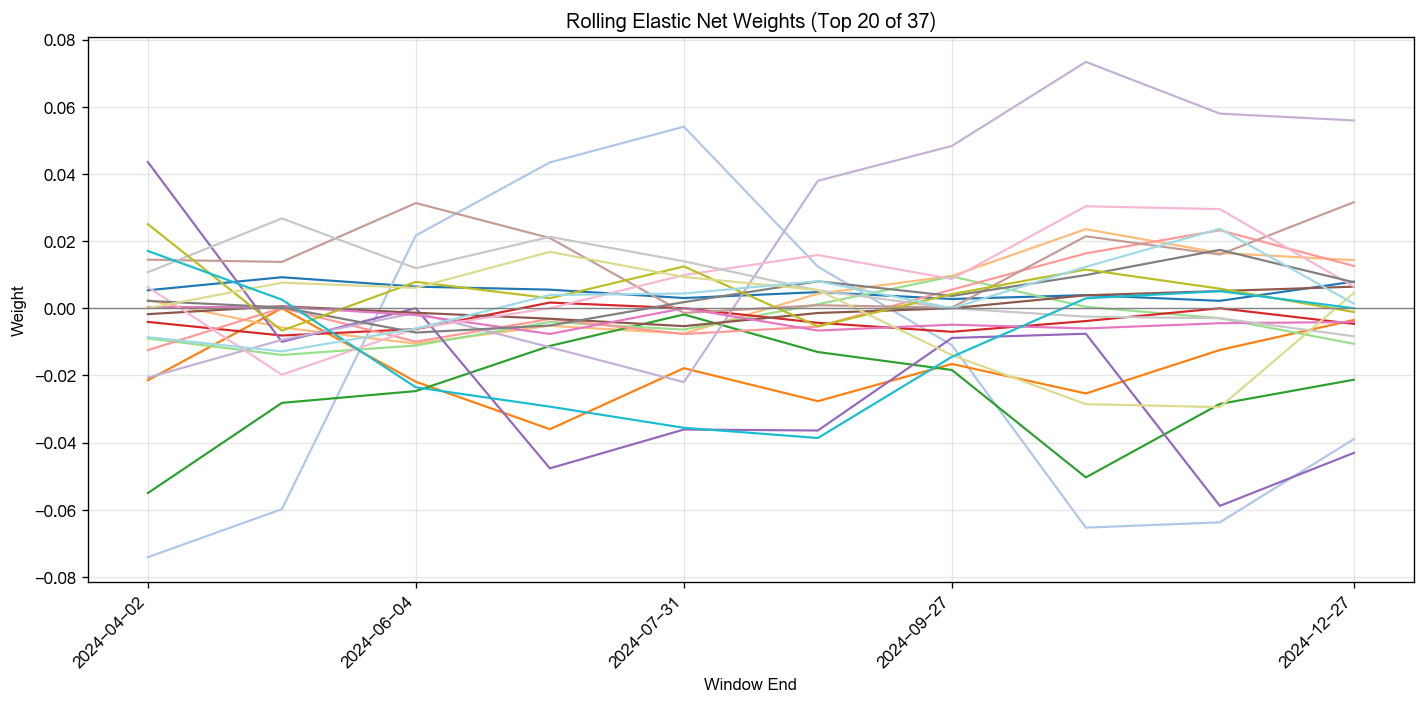
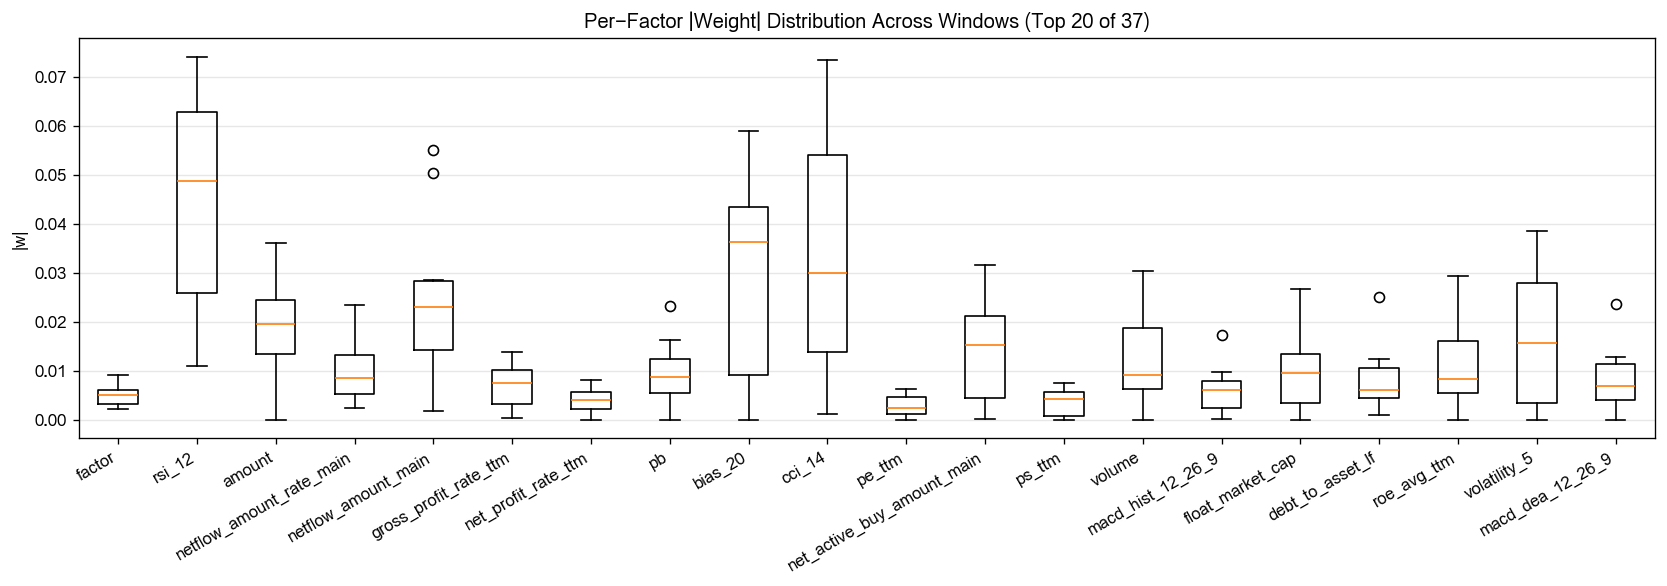
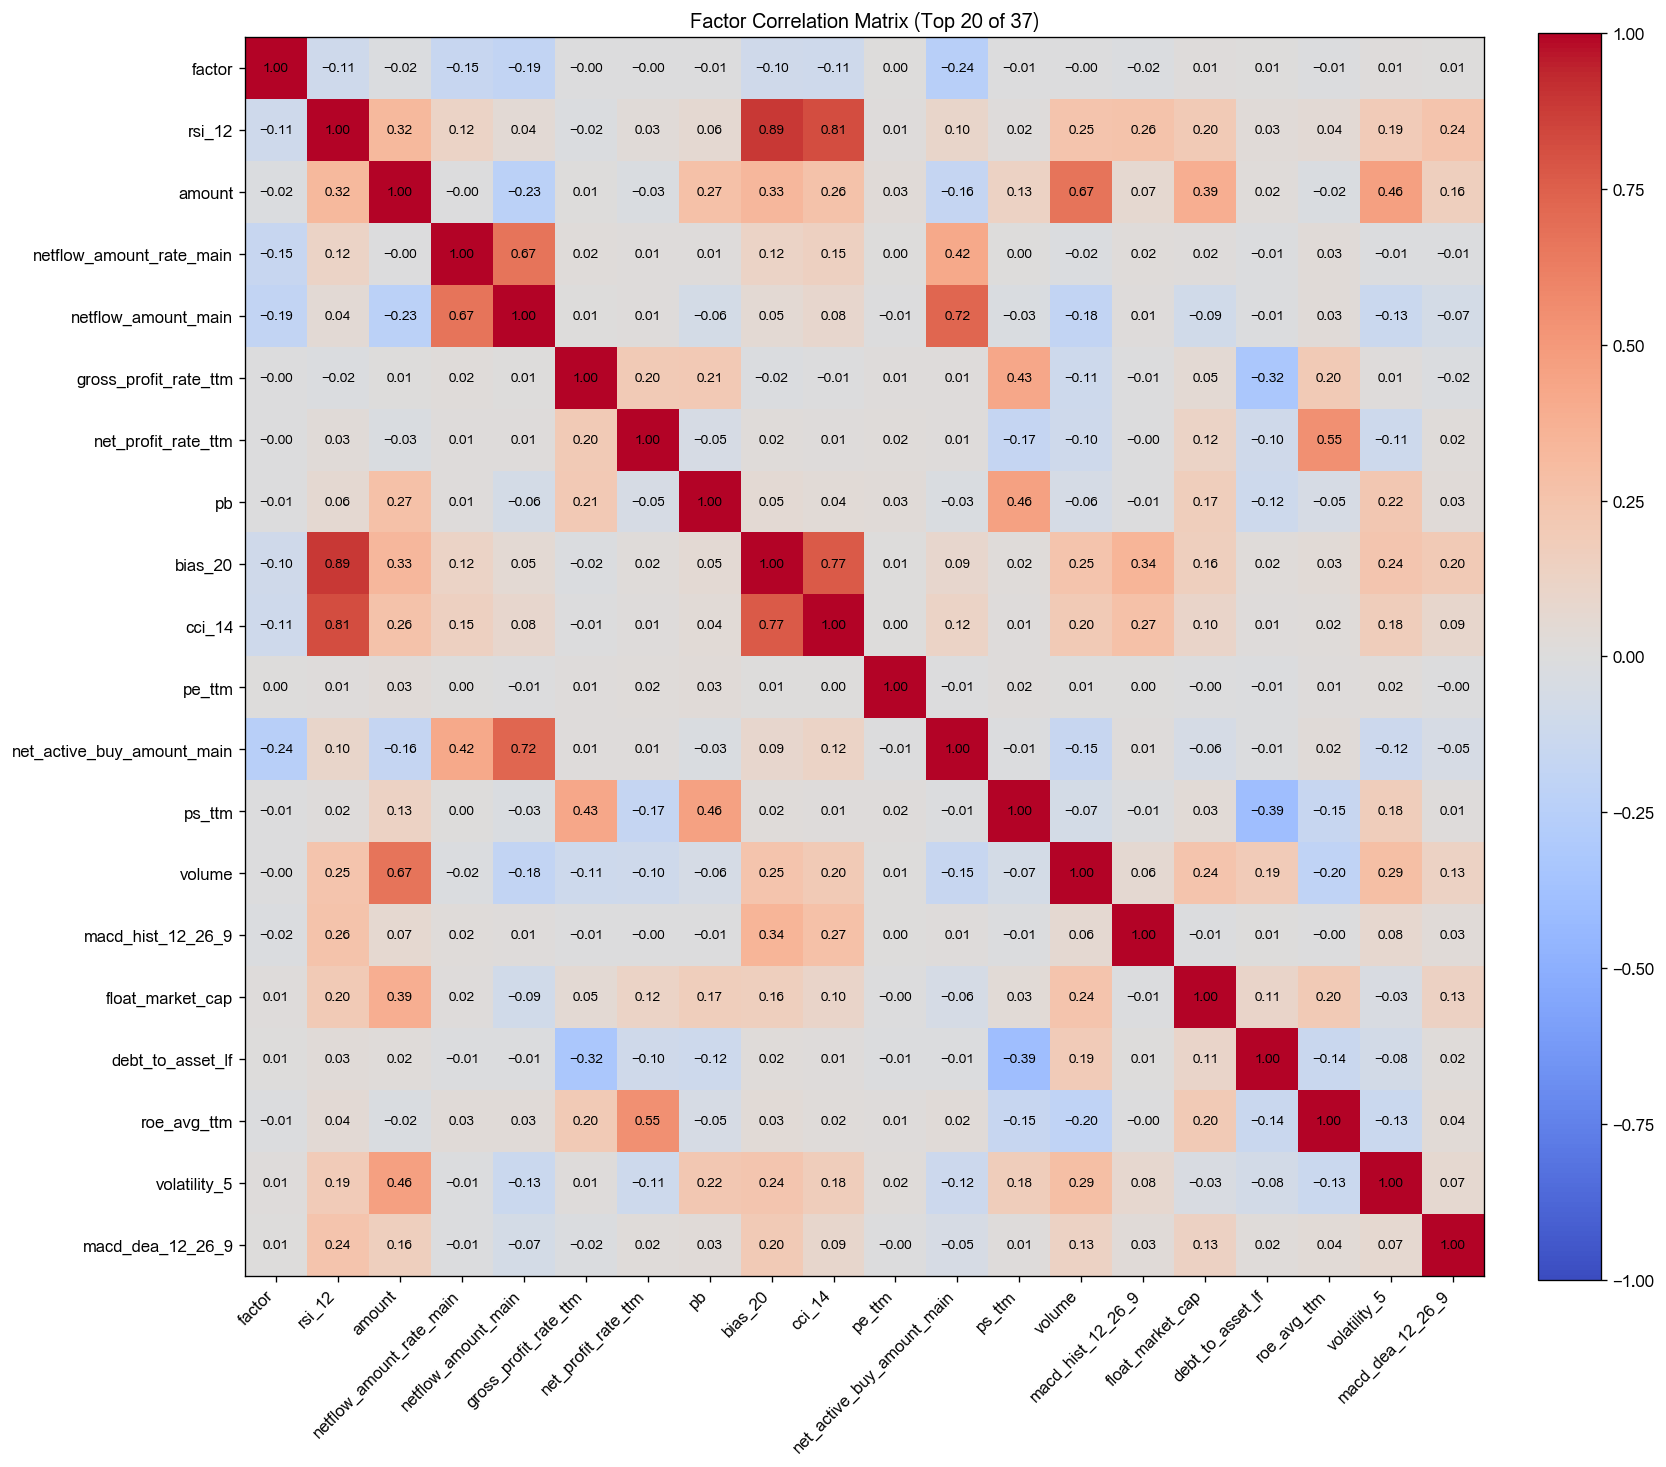

[2026-07-11 01:22:02] [warning  ] 返回的Outputs实例(size=34600362) 大于 64K, 将不会被缓存
[2026-07-11 01:22:02] [info     ] bigalpha_eval.v4 运行完成 [20.311s].


In [22]:



def main(datasources, start_date, end_date):
    import dai
    import pandas as pd

    table_name = datasources["bar1m"]
    
    # ========== 三个子因子的原始 SQL 表达式 ==========
    pressure_raw = """
        (
            CAST(bid_volume1 AS DOUBLE) - CAST(ask_volume1 AS DOUBLE)
        )
        / NULLIF(
            CAST(bid_volume1 AS DOUBLE) + CAST(ask_volume1 AS DOUBLE),
            0
        )
    """
    order_pressure_raw = """
        (
            CAST(bid_num_orders1 AS DOUBLE) - CAST(ask_num_orders1 AS DOUBLE)
        )
        / NULLIF(
            CAST(bid_num_orders1 AS DOUBLE) + CAST(ask_num_orders1 AS DOUBLE),
            0
        )
    """
    minute_return_raw = """
        (
            CAST(close AS DOUBLE) - CAST(open AS DOUBLE)
        )
        / NULLIF(CAST(open AS DOUBLE), 0)
    """
    # 新增：订单平均大小比率
    avg_order_size_ratio = """
        CASE
            WHEN CAST(bid_num_orders1 AS DOUBLE) > 0 AND CAST(ask_num_orders1 AS DOUBLE) > 0
            THEN
                (CAST(bid_volume1 AS DOUBLE) / CAST(bid_num_orders1 AS DOUBLE))
                /
                (CAST(ask_volume1 AS DOUBLE) / CAST(ask_num_orders1 AS DOUBLE))
            ELSE 1.0   -- 或无交易时视为中性
        END
    """



    # ========== 超参数（你可以网格搜索这三组值） ==========
    alpha = 1.5      # Pressure 指数（推荐 1~2）
    gamma = 0.7      # OrderPressure 指数（推荐 0.5~1）
    k=14
    # ========== 带符号的幂变换： sign(x) * |x|^p ==========
    def signed_power(expr, p):
        if p == 1:
            return expr   # 线性情况，不做变换，提升性能
        # 用 CASE WHEN 保持符号，ABS + POWER 实现 |x|^p
        return f"""
            CASE WHEN {expr} >= 0
                THEN POWER(ABS({expr}), {p})
                ELSE -POWER(ABS({expr}), {p})
            END
        """

    pressure = signed_power(pressure_raw, alpha)
    order_pressure = signed_power(order_pressure_raw, gamma)

    # 对 return 也可以直接用 TANH 压缩（一种非线性替代方案）
    # 如果你更相信“大涨幅/大跌幅应该被削平”，可以把下面两行注释掉
    # minute_return = f"TANH(10 * ({minute_return_raw}))"   # 10 是缩放系数，可调

    # 否则使用幂变换
    minute_return = f"TANH({k} * ({minute_return_raw}))"

    # ========== 最终的 SQL（保持等权平均，先不折腾加权） ==========
    sql = f"""
        SELECT
            date::DATE::DATETIME AS date,
            instrument,
            AVG( ({pressure}) * ({minute_return}) * ({order_pressure}) ) AS factor
        FROM {datasources['bar1m']}
        WHERE ({pressure_raw}) IS NOT NULL
        AND ({minute_return_raw}) IS NOT NULL
        AND ({order_pressure_raw}) IS NOT NULL
        GROUP BY date::DATE, instrument
        ORDER BY date, instrument
    """
    factor = dai.query(
        sql,
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()
    factor["date"] = pd.to_datetime(factor["date"]).dt.normalize()
    factor["factor"] = pd.to_numeric(factor["factor"], errors="coerce")



    import numpy as np
    import statsmodels.api as sm
    import pandas as pd

    # ========== 中性化部分 ==========
    # 1. 读取 exposure 表的市值和行业哑变量
    expo = dai.query(
        """SELECT date, instrument, float_market_cap,
                  AGRIFOREST, MINING, CHEM, IRONSTEEL, NONFERMETAL,
                  ELECTRONICS, AUTO, HOUSEAPP, FOODBEVER, TEXTILE,
                  LIGHTINDUS, HEALTH, UTILITIES, TRANSPORTATION,
                  REALESTATE, COMMETRADE, LEISERVICE, BANK, NONBANKFINAN,
                  CONGLOMERATES, CONMAT, BUILDDECO, ELECEQP, MACHIEQUIP,
                  AERODEF, COMPUTER, MEDIA, TELECOM, COAL, PETRO, ENVP, BEAUTY
           FROM bigalpha_2026_exposure""",
        filters={"date": [start_date, end_date]}
    ).df()
    expo["date"] = pd.to_datetime(expo["date"]).dt.normalize()
    expo["log_mktcap"] = np.log(np.maximum(expo["float_market_cap"], 1))  # 避免log(0)

    # 2. 合并
    factor = factor.merge(expo, on=["date", "instrument"], how="left")

    # 3. 定义行业哑变量（去掉基准行业以避免完全共线性）
    industry_cols = [
        "AGRIFOREST", "MINING", "CHEM", "IRONSTEEL", "NONFERMETAL",
        "ELECTRONICS", "AUTO", "HOUSEAPP", "FOODBEVER", "TEXTILE",
        "LIGHTINDUS", "HEALTH", "UTILITIES", "TRANSPORTATION",
        "REALESTATE", "COMMETRADE", "LEISERVICE", "BANK", "NONBANKFINAN",
        "CONMAT", "BUILDDECO", "ELECEQP", "MACHIEQUIP", "AERODEF",
        "COMPUTER", "MEDIA", "TELECOM", "COAL", "PETRO", "ENVP", "BEAUTY"
        # 注意：已去掉 CONGLOMERATES（综合），作为基准行业
    ]

    # 4. 逐日中性化
    def neutralize(df):
        # 回归所需字段不能缺失
        cols_needed = ["factor", "log_mktcap"] + industry_cols
        df = df.dropna(subset=cols_needed)
        if len(df) < 20:
            df["factor_neutral"] = np.nan
            return df

        X = df[industry_cols].astype(float).copy()
        X["log_mktcap"] = df["log_mktcap"].values
        X = sm.add_constant(X)          # 加截距项
        y = df["factor"].values
        model = sm.OLS(y, X).fit()
        df["factor_neutral"] = model.resid
        return df

    factor = factor.groupby("date", group_keys=False).apply(neutralize)
    factor = factor.dropna(subset=["factor_neutral"])

   

    # 与股票池对齐并输出
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]}
    ).df()
    stk_pool["date"] = pd.to_datetime(stk_pool["date"]).dt.normalize()

    result = (
        pd.merge(factor[["date", "instrument", "factor_neutral"]], stk_pool,
                 how="inner", on=["date", "instrument"])
        .rename(columns={"factor_neutral": "factor"})
        .sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )
    
    result["factor"] = -result["factor"]


    print(result)
    return result



 
if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'financial': 'bigalpha_2026_financial','bar1m':'bigalpha_2026_stock_bar1m'}

    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )